In [1]:
import os
import sys
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt


from kineticanalysis.generator.generator_track import (generate_tracks, generate_one_track)
from kineticanalysis.analysis.analysis_track import single_track_analysis, check_track_validity

In [2]:
# path_save = "/home/u2175049/Documents/Code/KineticAnalysis/notebook/figures/"
path = "/mnt/sda1/Sophie/2-KineticAnalysisData/2-Datas/05-Modelling/0-PierrePaper/"
path_save = path

In [3]:
prot_aa_size = {
    "32xsuntag": 800,  #768/32=24 , left 28
    "lacz": 1047,
    "small": 400,
}

In [4]:
prot_length = prot_aa_size["32xsuntag"]+prot_aa_size["small"]
elongation_rate = 5

In [30]:
first = True
for i in range(250):
    
    if i>=0 and i<50:
        elongation_rate = 1
    elif i>=50 and i<100:
        elongation_rate = 5
    elif i>=100 and i<150:
        elongation_rate = 10
    elif i>=150 and i<200:
        elongation_rate = 25
    elif i>=200 and i<250:
        elongation_rate = 50
        
    x_global, y_global, y_start_prot = generate_one_track(prot_length = prot_aa_size["lacz"], 
                                                      suntag_length = prot_aa_size["32xsuntag"], 
                                                      nb_suntag=32, 
                                                      fluo_one_suntag=4, 
                                                      translation_rate=elongation_rate, 
                                                      binding_rate=0.05,
                                                      step = 0.1,
                                                      length=85000, 
                                                       remove_point_beginning=10000)
    if first:
        datas = pd.DataFrame({"FRAME":x_global,
                              "MEAN_INTENSITY_CH1":y_global,
                              "TRACK_ID" : i,
                              "elongation_rate":elongation_rate
                             })
        first=False
    else:
        datas = pd.concat([datas, 
                           pd.DataFrame({"FRAME":x_global,
                                         "MEAN_INTENSITY_CH1":y_global,
                                         "TRACK_ID" : i,
                                         "elongation_rate":elongation_rate
                             })], ignore_index=True)

datas.to_csv(os.path.join(path, "datas_track_elongation_small.csv"))

In [31]:
datas

,FRAME,MEAN_INTENSITY_CH1,TRACK_ID,elongation_rate
0,0.0,4033.152,0,1
1,0.1,4033.776,0,1
2,0.2,4034.400,0,1
3,0.3,4035.024,0,1
4,0.4,4035.648,0,1
...,...,...,...,...
209999995,83999.5,128.000,249,50
209999996,83999.6,128.000,249,50
209999997,83999.7,128.000,249,50
209999998,83999.8,128.000,249,50


In [5]:
datas = pd.read_csv(os.path.join(path, "datas_track_elongation_lacz.csv"))

In [17]:
# datas = pd.read_csv(os.path.join(path, "datas_track_length_translation_rate_5_short_prot_134.csv"), index_col="Unnamed: 0")
# Utiliser t comme base de la boucle
prot_length = prot_aa_size["32xsuntag"]+prot_aa_size["small"]
first = True


# for i in range(20):
for i in np.concatenate([np.arange(20), np.arange(50,70), np.arange(100,120), np.arange(150,170), np.arange(200,220)]):
    print(i)   
        
    for t in [1, 5, 10,30,50,100, 300, 600]:
        dt = t*0.1
        for length_track in [60, 300, 600, 1800, 3000, 3600, 6000]:   
            nb_point = int(length_track/dt)
            
            datas2 = datas[datas["TRACK_ID"]==i][::t][:nb_point]
            datas2["FRAME"] = np.arange(nb_point)
            # if (len(np.unique(datas2["MEAN_INTENSITY_CH1"])) > 1) & (len(datas2) in [30,60,300,600,1200,1800,2700,3600]):
            if len(np.unique(datas2["MEAN_INTENSITY_CH1"])) > 2:
                
                (valid, x, y, x_fix, y_fix) = check_track_validity(datas2,
                                                       i,
                                                       normalise_intensity=1,
                                                       delta_t=dt,
                                                       rtol=1e-1,
                                                       nb_missing_point=0,
                                                       )
    
                for method in ["exact", "epitope", "approx"]:
                    (x_auto, 
                     y_auto, 
                     k, c,
                     elongation_r, 
                     translation_init_r,
                     perr) = single_track_analysis(x, 
                                                 y, 
                                                 delta_t = dt,
                                                 protein_size=prot_aa_size["lacz"],
                                                 suntag_size =prot_aa_size["32xsuntag"], 
                                                 repetition_suntag = 32,
                                                 mm=None,
                                                 method=method,
                                                 simulation=True)
                    if first:
                        results = pd.DataFrame({"elongation_r":elongation_r, 
                                                "init_translation_r":translation_init_r, 
                                                "dt":dt,
                                                "long_track":length_track, 
                                                "nb_point":datas2.shape[0],
                                                "k":k,
                                                "c":c,
                                               "id":i,
                                               "method":method,
                                                "elongation_input":datas2["elongation_rate"].iloc[0],
                                               "M/N": prot_aa_size["lacz"]/prot_aa_size["32xsuntag"]},
                                              index=[0])
                        first = False
                    
                    else:
                        results = pd.concat([results, 
                                        pd.DataFrame({"elongation_r":elongation_r, 
                                                      "init_translation_r":translation_init_r, 
                                                      "dt":dt, 
                                                      "long_track":length_track, 
                                                      "nb_point":datas2.shape[0],
                                                      "k":k,
                                                        "c":c,
                                                      "id":i,
                                                      "method":method,
                                                      "elongation_input":datas2["elongation_rate"].iloc[0],
                                                     "M/N": prot_aa_size["lacz"]/prot_aa_size["32xsuntag"]}, index=[0])
                                        ], ignore_index=True)
            else:
                print("ELSE")
                
results.to_csv(os.path.join(path, "result_track_elongation_lacz.csv"))

0


/home/u2175049/anaconda3/envs/kineticGUI/lib/python3.11/site-packages/kineticanalysis/analysis/analysis_track.py:137: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = optimize.curve_fit(function_approx,
/home/u2175049/anaconda3/envs/kineticGUI/lib/python3.11/site-packages/kineticanalysis/analysis/analysis_track.py:137: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = optimize.curve_fit(function_approx,
/home/u2175049/anaconda3/envs/kineticGUI/lib/python3.11/site-packages/kineticanalysis/analysis/analysis_track.py:137: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = optimize.curve_fit(function_approx,
/home/u2175049/anaconda3/envs/kineticGUI/lib/python3.11/site-packages/kineticanalysis/analysis/analysis_track.py:137: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = optimize.curve_fit(function_approx,
/home/u2175049/anaconda3/envs/kineticGUI/lib/pyt

ELSE


/home/u2175049/anaconda3/envs/kineticGUI/lib/python3.11/site-packages/kineticanalysis/analysis/analysis_track.py:137: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = optimize.curve_fit(function_approx,
/home/u2175049/anaconda3/envs/kineticGUI/lib/python3.11/site-packages/kineticanalysis/analysis/analysis_track.py:137: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = optimize.curve_fit(function_approx,
/home/u2175049/anaconda3/envs/kineticGUI/lib/python3.11/site-packages/kineticanalysis/analysis/analysis_track.py:137: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = optimize.curve_fit(function_approx,
/home/u2175049/anaconda3/envs/kineticGUI/lib/python3.11/site-packages/kineticanalysis/analysis/analysis_track.py:137: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = optimize.curve_fit(function_approx,
/home/u2175049/anaconda3/envs/kineticGUI/lib/pyt

ELSE


...

/home/u2175049/anaconda3/envs/kineticGUI/lib/python3.11/site-packages/kineticanalysis/analysis/analysis_track.py:137: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = optimize.curve_fit(function_approx,
/home/u2175049/anaconda3/envs/kineticGUI/lib/python3.11/site-packages/kineticanalysis/analysis/analysis_track.py:137: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = optimize.curve_fit(function_approx,
/home/u2175049/anaconda3/envs/kineticGUI/lib/python3.11/site-packages/kineticanalysis/analysis/analysis_track.py:137: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = optimize.curve_fit(function_approx,
/home/u2175049/anaconda3/envs/kineticGUI/lib/python3.11/site-packages/kineticanalysis/analysis/analysis_track.py:137: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = optimize.curve_fit(function_approx,
/home/u2175049/anaconda3/envs/kineticGUI/lib/pyt

ELSE


/home/u2175049/anaconda3/envs/kineticGUI/lib/python3.11/site-packages/kineticanalysis/analysis/analysis_track.py:137: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = optimize.curve_fit(function_approx,
/home/u2175049/anaconda3/envs/kineticGUI/lib/python3.11/site-packages/kineticanalysis/analysis/analysis_track.py:137: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = optimize.curve_fit(function_approx,
/home/u2175049/anaconda3/envs/kineticGUI/lib/python3.11/site-packages/kineticanalysis/analysis/analysis_track.py:137: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = optimize.curve_fit(function_approx,
/home/u2175049/anaconda3/envs/kineticGUI/lib/python3.11/site-packages/kineticanalysis/analysis/analysis_track.py:137: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = optimize.curve_fit(function_approx,
/home/u2175049/anaconda3/envs/kineticGUI/lib/pyt

ELSE


/home/u2175049/anaconda3/envs/kineticGUI/lib/python3.11/site-packages/kineticanalysis/analysis/analysis_track.py:137: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = optimize.curve_fit(function_approx,
/home/u2175049/anaconda3/envs/kineticGUI/lib/python3.11/site-packages/kineticanalysis/analysis/analysis_track.py:137: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = optimize.curve_fit(function_approx,
/home/u2175049/anaconda3/envs/kineticGUI/lib/python3.11/site-packages/kineticanalysis/analysis/analysis_track.py:137: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = optimize.curve_fit(function_approx,
/home/u2175049/anaconda3/envs/kineticGUI/lib/python3.11/site-packages/kineticanalysis/analysis/analysis_track.py:137: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = optimize.curve_fit(function_approx,
/home/u2175049/anaconda3/envs/kineticGUI/lib/pyt

In [18]:
results.groupby(by=['elongation_input', "method", "dt"])[['elongation_r','init_translation_r', 'k', 'c', "long_track",]].mean()

elongation_r  init_translation_r           k  \
elongation_input method dt                                                   
1                approx 0.1       9.189416            8.625668  499.152325   
                        0.5       9.182492            8.626001  499.199002   
                        1.0       9.162849            8.619777  499.263371   
                        3.0       9.144337            8.648937  499.430428   
                        5.0      75.518232            9.859694  315.443383   
...                                    ...                 ...         ...   
50               exact  3.0      94.735688            0.124399    3.789428   
                        5.0     104.137398            0.119189    4.165496   
                        10.0    120.421369            0.197585    4.816855   
                        30.0     83.621472            0.096225    3.344859   
                        60.0     70.217847            0.086193    2.808714   

                                     c   long_track  
elongation_input method dt                           
1                approx 0.1   8.625668  2194.285714  
                        0.5   8.626001  2194.285714  
                        1.0   8.619777  2194.285714  
                        3.0   8.648937  2194.285714  
                        5.0   9.859694  2194.285714  
...                                ...          ...  
50               exact  3.0   0.124399  2209.640288  
                        5.0   0.119189  2209.640288  
                        10.0  0.197585  2209.640288  
                        30.0  0.096225  2550.000000  
                        60.0  0.086193  2550.000000  

[120 rows x 5 columns]

In [19]:
results = pd.read_csv(os.path.join(path, "result_track_elongation_lacz.csv"))
for i, data in results.iterrows():
    # results.loc[i, "box"] = str(results.loc[i,"elongation_input"]) + "_"+str(results.loc[i, "dt"])+"_"+str(results.loc[i, "long_track"])+"_"+str(results.loc[i, "method"])
    results.loc[i, "box"] = str(results.loc[i,"elongation_input"]) + "_"+str(results.loc[i, "dt"])+"_"+str(results.loc[i, "method"])

In [20]:
ei = 10
r = results[(results["method"]=="epitope")& (results["elongation_input"]==ei)][['elongation_r', 'init_translation_r', 'dt', 'long_track', 'nb_point',
       'k', 'c', 'id', 'elongation_input', 'M/N']]
results_group = r.groupby(["dt", "long_track"]).median()
results_group.reset_index(inplace=True)

results_group["elongation_r_ratio"]= (results_group['elongation_r']-ei)/ei*100

results_group["init_translation_r_ratio"]= (results_group['init_translation_r']-0.05)/0.05*100

results_group

,dt,long_track,elongation_r,init_translation_r,nb_point,k,c,id,elongation_input,M/N,elongation_r_ratio,init_translation_r_ratio
0,0.1,60,43.743674,9.166168,600.0,1.749747,9.166168,109.5,10.0,1.30875,337.436736,18232.335471
1,0.1,300,9.380543,0.218720,3000.0,0.375222,0.218720,109.5,10.0,1.30875,-6.194570,337.439809
2,0.1,600,5.380281,0.090640,6000.0,0.215211,0.090640,109.5,10.0,1.30875,-46.197192,81.280134
3,0.1,1800,4.445735,0.060751,18000.0,0.177829,0.060751,109.5,10.0,1.30875,-55.542651,21.501820
4,0.1,3000,4.721100,0.062975,30000.0,0.188844,0.062975,109.5,10.0,1.30875,-52.789003,25.949557
5,0.1,3600,4.802376,0.058092,36000.0,0.192095,0.058092,109.5,10.0,1.30875,-51.976237,16.184816
6,0.1,6000,4.544874,0.058200,60000.0,0.181795,0.058200,109.5,10.0,1.30875,-54.551263,16.400013
7,0.5,60,43.873629,9.065005,120.0,1.754945,9.065005,109.5,10.0,1.30875,338.736293,18030.009169
8,0.5,300,9.384501,0.219547,600.0,0.375380,0.219547,109.5,10.0,1.30875,-6.154992,339.093165
9,0.5,600,5.376608,0.090819,1200.0,0.215064,0.090819,109.5,10.0,1.30875,-46.233916,81.637496


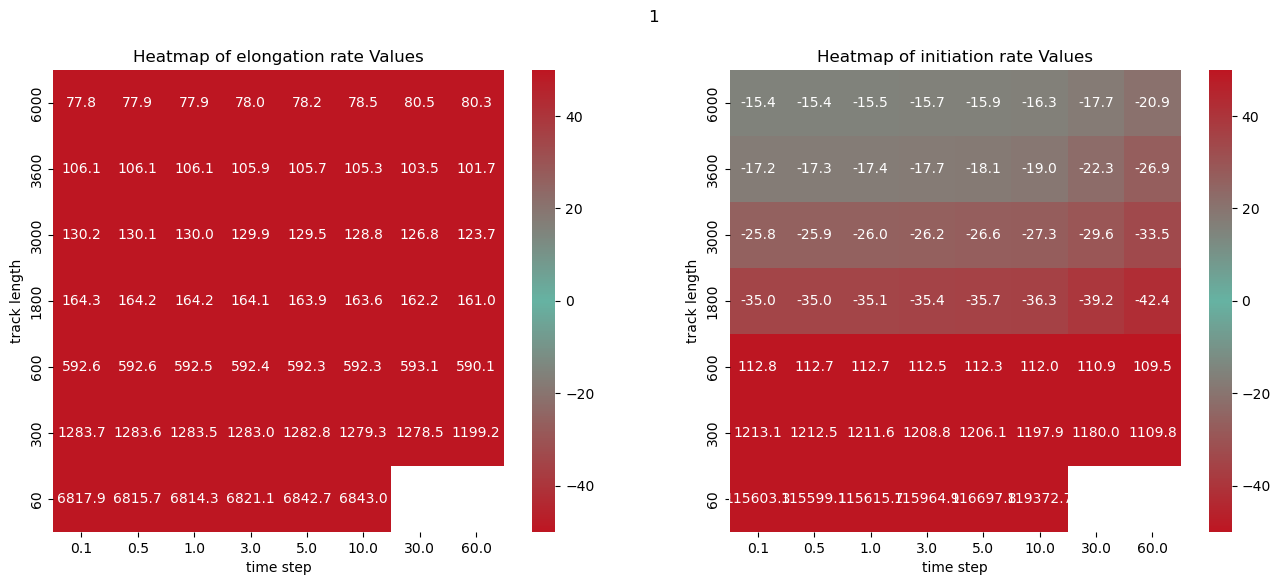

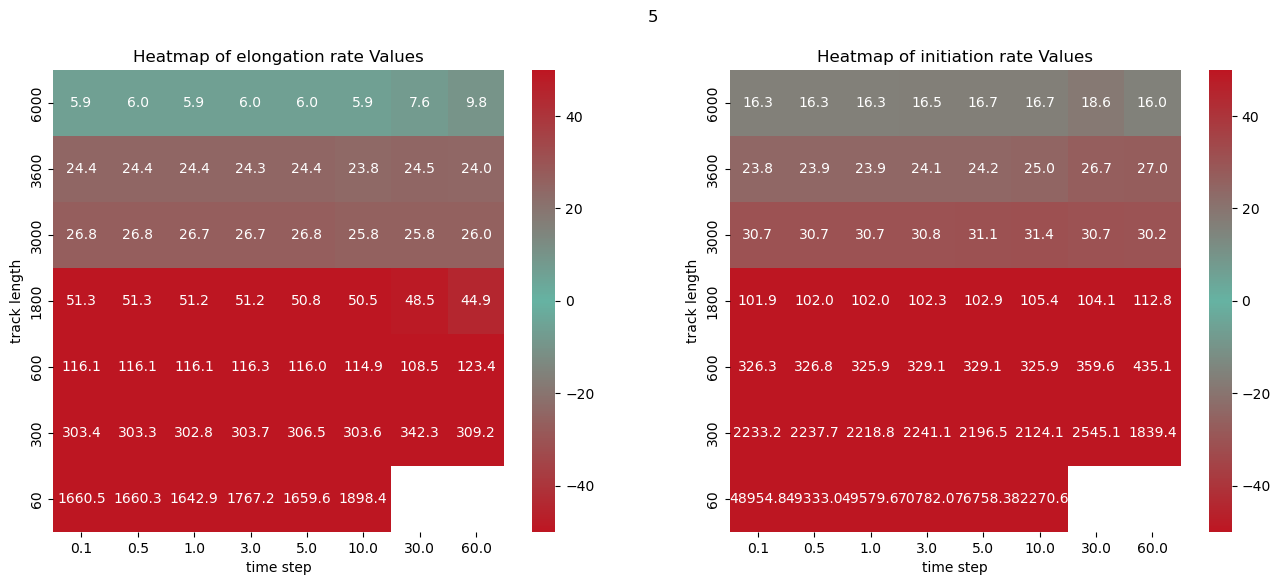

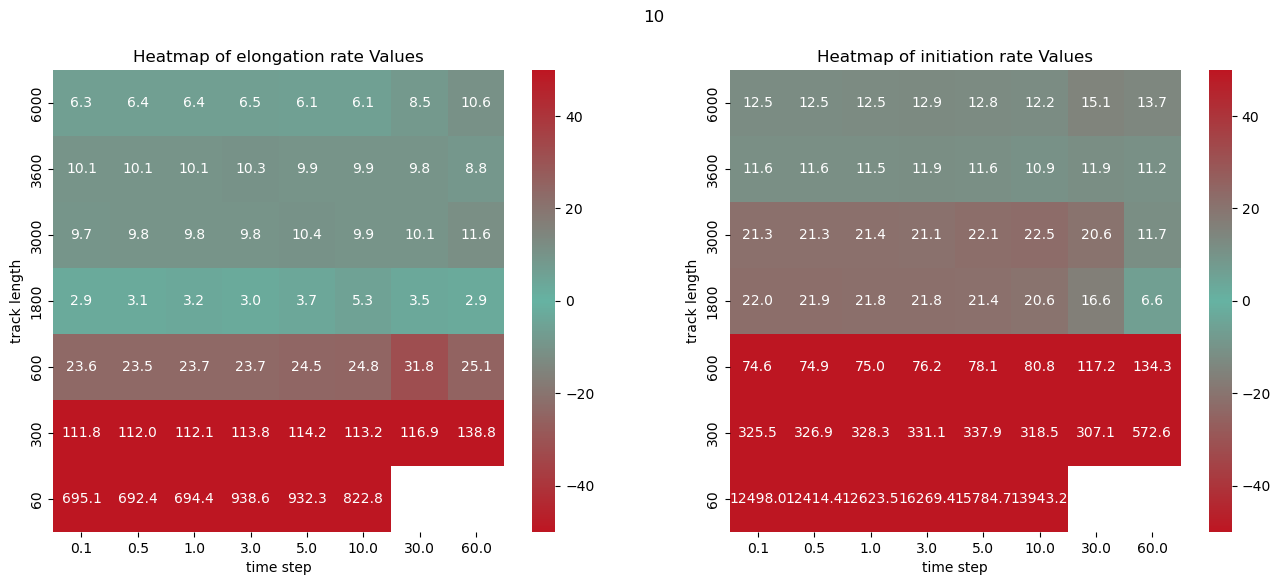

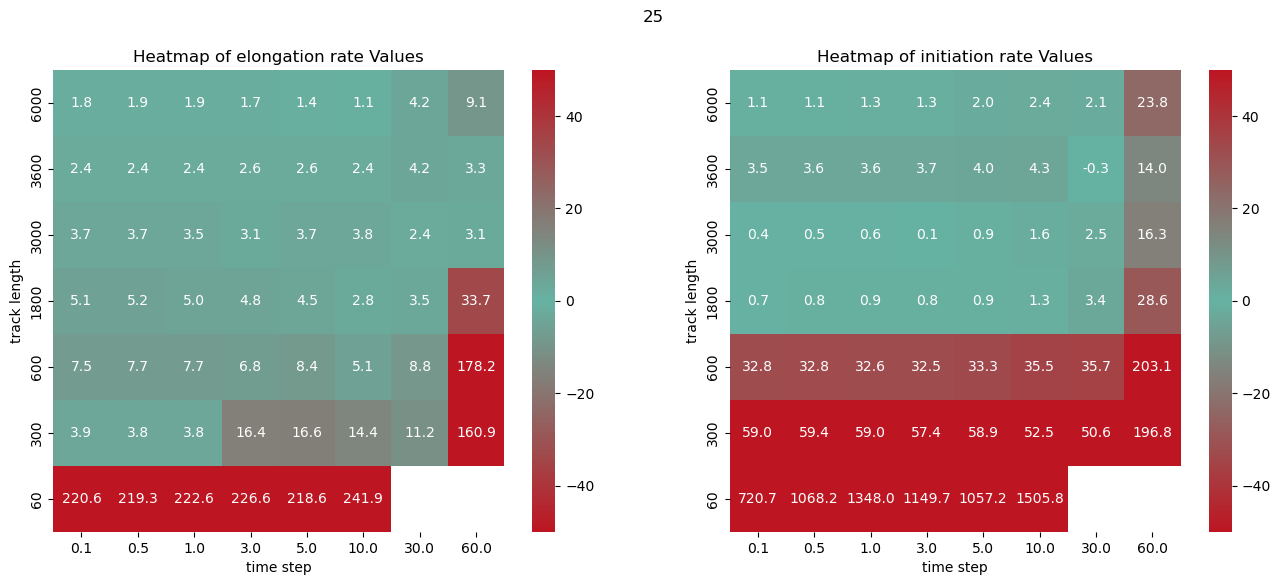

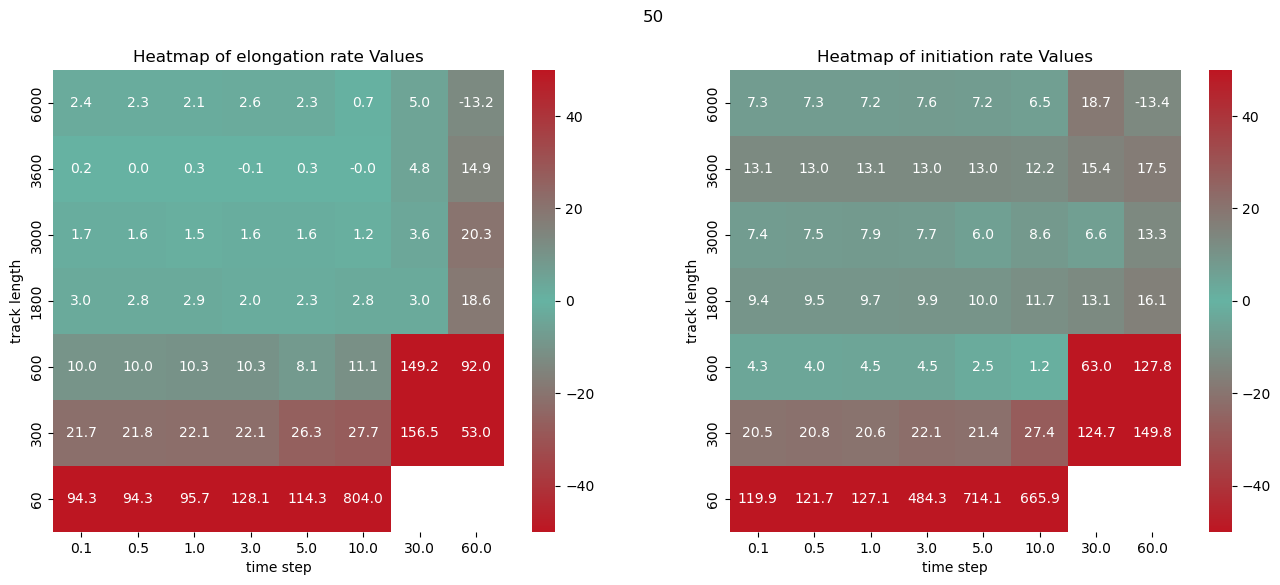

In [21]:
import seaborn as sns
from matplotlib.colors import ListedColormap

N=256
vals = np.ones((N, 4))
vals[:, 0] = np.linspace(190/256, 102/256, N)
vals[:, 1] = np.linspace(22/256, 179/256, N)
vals[:, 2] = np.linspace(34/256, 163/256, N)
newcmp = ListedColormap(vals)

# Create a symmetric colormap
color = plt.cm.Reds
color_r = plt.cm.Reds_r

color = newcmp.reversed()
color_r = newcmp

combined_colors = ListedColormap(color_r(np.linspace(0, 1, 128)).tolist() +
                                 color(np.linspace(0, 1, 128)).tolist())


for ei in [1,5,10,25,50]:
    # ei = 10
    r = results[(results["method"]=="exact")& (results["elongation_input"]==ei)][['elongation_r', 'init_translation_r', 'dt', 'long_track', 'nb_point',
           'k', 'c', 'id', 'elongation_input', 'M/N']]
    results_group = r.groupby(["dt", "long_track"]).median()
    results_group.reset_index(inplace=True)
    
    results_group["elongation_r_ratio"]= (results_group['elongation_r']-ei)/ei*100
    
    results_group["init_translation_r_ratio"]= (results_group['init_translation_r']-0.05)/0.05*100
    
    
    # Create the heatmap
    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(16, 6))
    # plt.figure(figsize=(8, 6))
    heatmap_data = results_group.pivot(index='long_track', columns='dt', values='elongation_r_ratio')

    ax1 = sns.heatmap(heatmap_data, 
                     annot=True, 
                     fmt=".1f", 
                     cmap=combined_colors,
                     vmin = -50,
                     vmax = 50,
                     ax=ax1)
    # Invert the y-axis
    ax1.invert_yaxis()
    ax1.set_title("Heatmap of elongation rate Values")
    ax1.set_xlabel("time step")
    ax1.set_ylabel("track length")
    
    
    
    heatmap_data = results_group.pivot(index='long_track', columns='dt', values='init_translation_r_ratio')
    ax2 = sns.heatmap(heatmap_data, 
                     annot=True, 
                     fmt=".1f", 
                     cmap=combined_colors,
                     vmin = -50,
                     vmax = 50, 
                      ax = ax2
                    )
    # Invert the y-axis
    ax2.invert_yaxis()
    ax2.set_title("Heatmap of initiation rate Values")
    ax2.set_xlabel("time step")
    
    ax2.set_ylabel("track length")

    fig.suptitle(str(ei))

    fig.savefig(os.path.join(path, "lacz_elong_"+str(ei)+"_exact.png"))